# Assignment 3: hierarchical clustering (Daniel)

Method: agglomerative hierarchical clustering with Ward linkage on z scored genes.
Samples: all 89 anterior cingulate cortex (AnCg) libraries, all four diagnoses.
Teammates: Vicky ran k-means, Alice ran PAM.

Why Ward on z scored genes: Ward merges the two clusters that add the least within cluster
variance, which only makes sense with Euclidean distance. Z scoring each gene first means a
highly expressed gene cannot dominate the distance just because its numbers are bigger.

Outputs:
- `results/a3_labels_hclust.tsv`: every cluster assignment, one column per version (shared with the team for the combined heatmap)
- `results/a3_hclust_k_summary.tsv`: cluster sizes, silhouette and batch check for k = 2 to 5
- `results/a3_hclust_chisq_table.tsv`: all chi square tests with BH adjusted p values
- `plots/a3_hclust_dendrogram.png`, `plots/a3_hclust_k_composition.png`, `plots/a3_hclust_genecount.png`

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, set_link_color_palette
from scipy.stats import chi2_contingency
from sklearn.metrics import silhouette_score, adjusted_rand_score
from statsmodels.stats.multitest import multipletests

os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)

# colors used in every figure, so a diagnosis is always the same color
DX_ORDER = ["control", "major depression", "bipolar disorder", "schizophrenia"]
DX_NAME = {"control": "Control", "major depression": "Depression",
           "bipolar disorder": "Bipolar", "schizophrenia": "Schizophrenia"}
DX_COLOR = {"control": "#9a9893", "major depression": "#1baf7a",
            "bipolar disorder": "#2a78d6", "schizophrenia": "#eb6834"}
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({"font.size": 10, "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False,
                     "axes.spines.right": False, "savefig.dpi": 200, "savefig.bbox": "tight"})

## Step 1: load the data processed in Assignment 2
These are the per library files my Assignment 2 notebook wrote (duplicate SRR runs already averaged,
266 libraries). They are gitignored, so if they are missing the cell rebuilds them from the raw download
with exactly the Assignment 2 code.

In [2]:
EXPR_LIB, META_LIB = "data/expr_by_library.tsv.gz", "data/meta_by_library.tsv"

if os.path.exists(EXPR_LIB) and os.path.exists(META_LIB):
    expr_lib = pd.read_csv(EXPR_LIB, sep="\t", index_col=0)
    meta_lib = pd.read_csv(META_LIB, sep="\t", index_col=0)
else:
    expr = pd.read_csv("SRP_counts.tsv.gz", sep="\t", index_col="Gene")
    meta = pd.read_csv("metadata.tsv.gz", sep="\t")
    assert list(expr.columns) == meta.refinebio_accession_code.tolist()
    meta[["region", "dx"]] = meta.refinebio_subject.str.split("_", n=1, expand=True)
    meta["donor"] = meta.refinebio_title.str.split("_").str[0]
    run_to_lib = meta.set_index("refinebio_accession_code").refinebio_title
    expr_lib = expr.T.groupby(run_to_lib).mean().T          # 69 duplicate runs averaged
    meta_lib = (meta.drop_duplicates("refinebio_title").set_index("refinebio_title")
                    .loc[expr_lib.columns])
    os.makedirs("data", exist_ok=True)
    expr_lib.to_csv(EXPR_LIB, sep="\t")
    meta_lib.to_csv(META_LIB, sep="\t")

# sequencing batch, inferred from the SL library number (SL3xxxx = batch B)
sl = meta_lib.index.str.extract(r"SL(\d+)")[0].astype(int).values
meta_lib["batch"] = np.where(sl > 20000, "B", "A")

# anterior cingulate only, log2(x + 1), keep genes with median above 0 in these samples
meta_a = meta_lib[meta_lib.region == "ancg"].copy()
log_expr = np.log2(expr_lib[meta_a.index] + 1)
log_expr = log_expr[log_expr.median(axis=1) > 0]

print("genes x libraries:", log_expr.shape)
print(meta_a.dx.value_counts().reindex(DX_ORDER).to_string())
print("batch B libraries:", (meta_a.batch == "B").sum())

genes x libraries: (34916, 89)
dx
control             22
major depression    22
bipolar disorder    22
schizophrenia       23
batch B libraries: 17


## Step 2a: the 5,000 most variable genes
Genes are ranked once by variance across the 89 libraries. `top_z(n)` returns a samples x genes matrix of
the top n genes, z scored per gene. Using a function (instead of reassigning one `X` variable in a loop)
keeps the 5,000 gene matrix from being silently replaced by another gene count.

In [3]:
gene_rank = log_expr.var(axis=1).sort_values(ascending=False).index

def top_z(n):
    X = log_expr.loc[gene_rank[:n]].T            # rows = libraries, columns = genes
    return (X - X.mean()) / X.std()

Z5000 = top_z(5000)
print(Z5000.shape)

(89, 5000)


## Step 2b to 2d: Ward hierarchical clustering on 5,000 genes, cut at k = 2 to 5
Hierarchical clustering builds the whole tree once; choosing k just means choosing where to cut it.
The merge heights tell you where the natural cut is: a big jump between the last merges means the
groups being joined are far apart.

In [4]:
tree = linkage(Z5000.values, method="ward")
print("last six merge heights:", np.round(tree[-6:, 2], 1))

KS = [2, 3, 4, 5]
labels = pd.DataFrame(index=meta_a.index)
labels.index.name = "refinebio_title"
summary = []
for k in KS:
    lab = fcluster(tree, k, criterion="maxclust")
    labels[f"g5000_k{k}"] = lab
    sizes = np.bincount(lab)[1:]
    summary.append({
        "k": k,
        "cluster_sizes": " / ".join(map(str, sizes)),
        "silhouette": silhouette_score(Z5000, lab),
        "batch_chi2_p": chi2_contingency(pd.crosstab(lab, meta_a.batch))[1],
    })
    print(f"\n=== k = {k} ===")
    tab = pd.crosstab(lab, meta_a.dx).reindex(columns=DX_ORDER)
    tab["batch B"] = pd.crosstab(lab, meta_a.batch).get("B", 0)
    print(tab.rename(columns=DX_NAME).to_string())

summary = pd.DataFrame(summary)
summary.to_csv("results/a3_hclust_k_summary.tsv", sep="\t", index=False)
summary.round(3)

last six merge heights: [152.  161.2 183.6 202.2 260.1 445.7]



=== k = 2 ===
dx     Control  Depression  Bipolar  Schizophrenia  batch B
row_0                                                      
1            0           0        8              7        2
2           22          22       14             16       15

=== k = 3 ===
dx     Control  Depression  Bipolar  Schizophrenia  batch B
row_0                                                      
1            0           0        8              7        2
2            8           7        4              6        0
3           14          15       10             10       15

=== k = 4 ===
dx     Control  Depression  Bipolar  Schizophrenia  batch B
row_0                                                      
1            0           0        2              1        0
2            0           0        6              6        2
3            8           7        4              6        0
4           14          15       10             10       15

=== k = 5 ===
dx     Control  Depression  Bipolar  Sch

,k,cluster_sizes,silhouette,batch_chi2_p
0,2,15 / 74,0.306,0.793
1,3,15 / 25 / 49,0.108,0.005
2,4,3 / 12 / 25 / 49,0.108,0.013
3,5,3 / 12 / 25 / 14 / 35,0.091,0.000


**What changes with k.** The cuts are nested: going from k to k+1 always splits one existing cluster.
- k = 2: a 15 library cluster that is only schizophrenia and bipolar patients (no controls, no depression).
- k = 3: the large cluster splits into 25 and 49. The 25 contains no batch B libraries.
- k = 4: the patient subgroup splits off 3 extreme libraries.
- k = 5: one new cluster is almost exactly the SL3xxxx sequencing batch.

So the strongest split in the data is disease associated, and the batch only becomes its own cluster at k = 5.
Silhouette is highest at k = 2 and falls sharply after it.

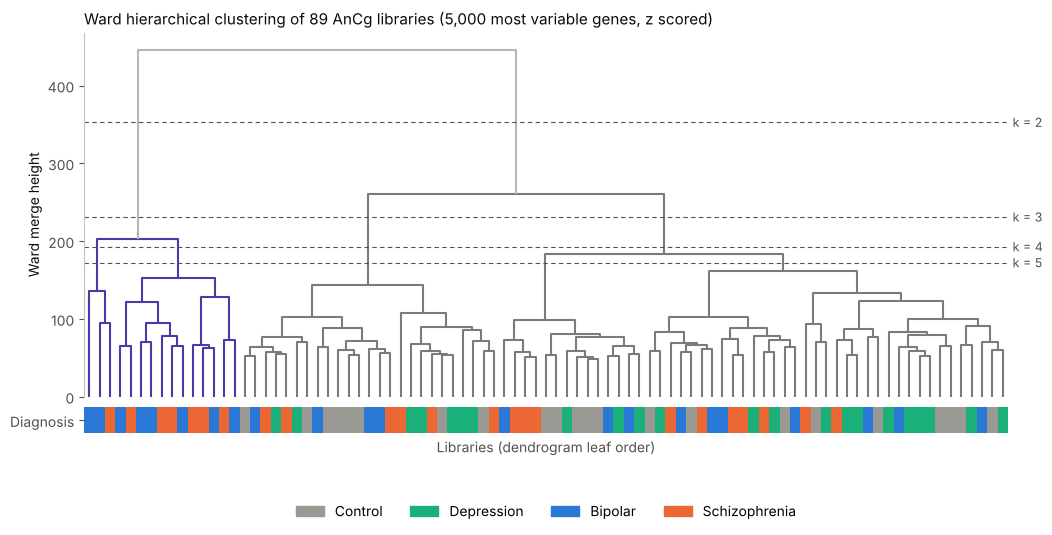

In [5]:
# Figure: dendrogram with the cut height for each k and a diagnosis strip under the leaves
cut_heights = {k: (tree[-k, 2] + tree[-(k - 1), 2]) / 2 for k in KS}

fig = plt.figure(figsize=(11, 5.2))
ax = fig.add_axes([0.06, 0.24, 0.84, 0.70])
set_link_color_palette(["#4a3aa7", "#7d7b75"])
dn = dendrogram(tree, ax=ax, color_threshold=cut_heights[2], above_threshold_color="#b9b7af",
                no_labels=True)
set_link_color_palette(None)
for k, h in cut_heights.items():
    ax.axhline(h, color=MUTED, lw=0.8, ls=(0, (4, 3)))
    ax.text(ax.get_xlim()[1] * 1.005, h, f"k = {k}", va="center", fontsize=9, color=MUTED)
ax.set_ylabel("Ward merge height")
ax.set_title("Ward hierarchical clustering of 89 AnCg libraries (5,000 most variable genes, z scored)",
             loc="left", fontsize=11, color=INK)
ax.spines["bottom"].set_visible(False)

strip = fig.add_axes([0.06, 0.17, 0.84, 0.05])
leaf_dx = meta_a.dx.iloc[dn["leaves"]].values
strip.imshow([[tuple(int(DX_COLOR[d][i:i + 2], 16) / 255 for i in (1, 3, 5)) for d in leaf_dx]],
             aspect="auto")
strip.set_yticks([0]); strip.set_yticklabels(["Diagnosis"]); strip.set_xticks([])
for s in strip.spines.values(): s.set_visible(False)
strip.set_xlabel("Libraries (dendrogram leaf order)", color=MUTED)
fig.legend(handles=[Patch(color=DX_COLOR[d], label=DX_NAME[d]) for d in DX_ORDER],
           loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.48, -0.02))
fig.savefig("plots/a3_hclust_dendrogram.png")
plt.show()

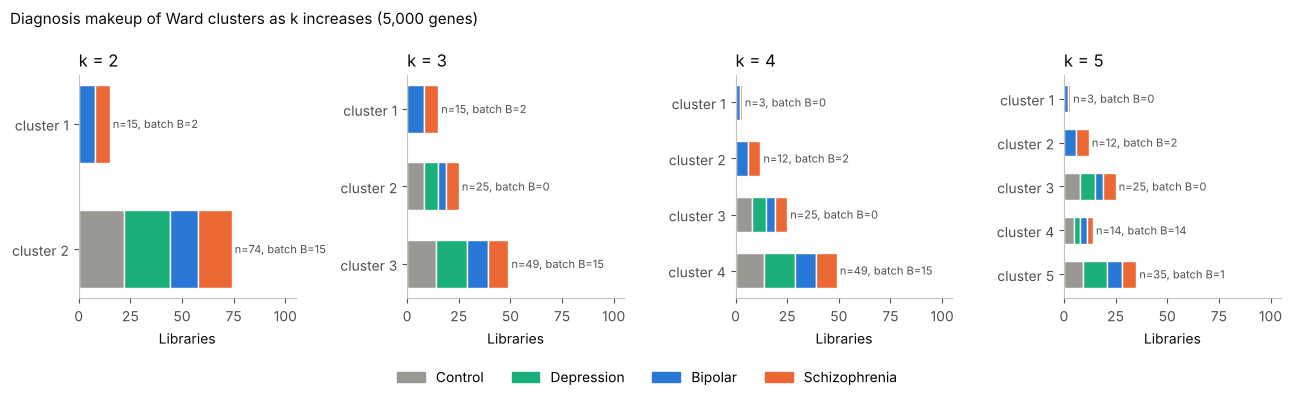

In [6]:
# Figure: diagnosis makeup of every cluster at each k
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharex=True)
for ax, k in zip(axes, KS):
    tab = pd.crosstab(labels[f"g5000_k{k}"], meta_a.dx).reindex(columns=DX_ORDER, fill_value=0)
    nb = pd.crosstab(labels[f"g5000_k{k}"], meta_a.batch).get("B", pd.Series(0, index=tab.index))
    left = np.zeros(len(tab))
    y = np.arange(len(tab))[::-1]
    for d in DX_ORDER:
        ax.barh(y, tab[d], left=left, color=DX_COLOR[d], height=0.62, edgecolor="white", linewidth=1)
        left += tab[d].values
    for yi, tot, b in zip(y, left, nb.values):
        ax.text(tot + 1.5, yi, f"n={int(tot)}, batch B={int(b)}", va="center", fontsize=8, color=MUTED)
    ax.set_yticks(y); ax.set_yticklabels([f"cluster {c}" for c in tab.index])
    ax.set_title(f"k = {k}", loc="left", color=INK)
    ax.set_xlim(0, 105)
    ax.set_xlabel("Libraries")
fig.legend(handles=[Patch(color=DX_COLOR[d], label=DX_NAME[d]) for d in DX_ORDER],
           loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.1))
fig.suptitle("Diagnosis makeup of Ward clusters as k increases (5,000 genes)", x=0.01, ha="left",
             fontsize=11, color=INK)
fig.tight_layout()
fig.savefig("plots/a3_hclust_k_composition.png")
plt.show()

### Parameter check: linkage method
Same 5,000 genes, average linkage on correlation distance (what the Assignment 2 heatmap used).
The crosstab shows how the average linkage clusters line up with the Ward clusters at k = 3.

In [7]:
avg_tree = linkage(top_z(5000).values, method="average", metric="correlation")
for k in KS:
    lab_avg = fcluster(avg_tree, k, "maxclust")
    print(f"average linkage k={k}: sizes {np.bincount(lab_avg)[1:]}, "
          f"ARI vs Ward k=2 = {adjusted_rand_score(labels['g5000_k2'], lab_avg):.2f}")
    if k == 2:
        avg_k2 = lab_avg
pd.crosstab(pd.Series(avg_k2, index=meta_a.index, name="average k=2"), labels["g5000_k3"].rename("Ward k=3"))

average linkage k=2: sizes [25 64], ARI vs Ward k=2 = 0.56
average linkage k=3: sizes [25 30 34], ARI vs Ward k=2 = 0.19
average linkage k=4: sizes [25 30 26  8], ARI vs Ward k=2 = 0.14
average linkage k=5: sizes [25  5 25 26  8], ARI vs Ward k=2 = 0.10


Ward k=3,1,2,3
average k=2,,,
1,15,1,9
2,0,24,40


Average linkage at k = 2 gives a looser cluster of 25 that contains all 15 libraries of the Ward subgroup
plus 10 more (mostly patients). So the linkage choice changes where the boundary sits, not whether the
patient subgroup exists.

## Step 2e: rerun with 10, 100, 1,000 and 10,000 genes
k is held at 2 so that any difference comes from the genes, not from the cut.
ARI (adjusted Rand index) measures how similar two clusterings are: 1 is identical, 0 is chance.

In [8]:
GENE_COUNTS = [10, 100, 1000, 5000, 10000]
for n in GENE_COUNTS:
    if n != 5000:
        labels[f"g{n}_k2"] = fcluster(linkage(top_z(n).values, method="ward"), 2, "maxclust")

gene_cols = [f"g{n}_k2" for n in GENE_COUNTS]
for c in gene_cols:
    tab = pd.crosstab(labels[c], meta_a.dx).reindex(columns=DX_ORDER, fill_value=0)
    print(f"\n{c}  ARI vs 5,000 genes = {adjusted_rand_score(labels['g5000_k2'], labels[c]):.2f}")
    print(tab.rename(columns=DX_NAME).to_string())

ari = pd.DataFrame([[adjusted_rand_score(labels[a], labels[b]) for b in gene_cols] for a in gene_cols],
                   index=GENE_COUNTS, columns=GENE_COUNTS)
ari.round(2)


g10_k2  ARI vs 5,000 genes = 0.20
dx      Control  Depression  Bipolar  Schizophrenia
g10_k2                                             
1             6           8       12             11
2            16          14       10             12

g100_k2  ARI vs 5,000 genes = 0.68
dx       Control  Depression  Bipolar  Schizophrenia
g100_k2                                             
1              1           0        7              5
2             21          22       15             18

g1000_k2  ARI vs 5,000 genes = 0.89
dx        Control  Depression  Bipolar  Schizophrenia
g1000_k2                                             
1               0           0        7              6
2              22          22       15             17

g5000_k2  ARI vs 5,000 genes = 1.00
dx        Control  Depression  Bipolar  Schizophrenia
g5000_k2                                             
1               0           0        8              7
2              22          22       14             16

g1

,10,100,1000,5000,10000
10,1.00,0.20,0.16,0.20,0.16
100,0.20,1.00,0.77,0.68,0.76
1000,0.16,0.77,1.00,0.89,0.88
5000,0.20,0.68,0.89,1.00,0.77
10000,0.16,0.76,0.88,0.77,1.00


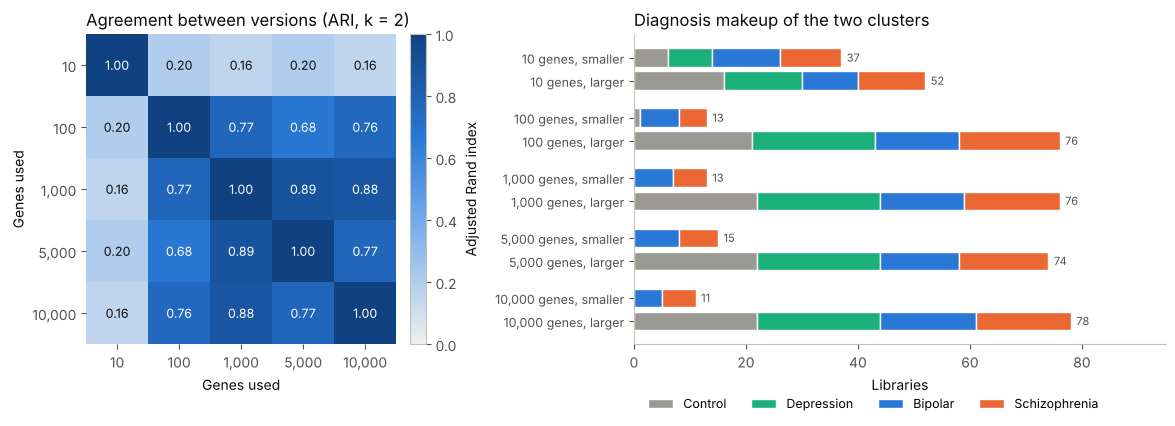

In [9]:
# Figure: agreement between gene counts (left) and diagnosis makeup of each cluster (right)
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1, 1.5]})
blues = plt.matplotlib.colors.LinearSegmentedColormap.from_list("b", ["#f0efec", "#86b6ef", "#2a78d6", "#104281"])
im = axl.imshow(ari.values, cmap=blues, vmin=0, vmax=1)
for i in range(len(ari)):
    for j in range(len(ari)):
        v = ari.values[i, j]
        axl.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color="white" if v > 0.6 else INK)
ticks = [f"{n:,}" for n in GENE_COUNTS]
axl.set_xticks(range(5)); axl.set_xticklabels(ticks); axl.set_yticks(range(5)); axl.set_yticklabels(ticks)
axl.set_xlabel("Genes used"); axl.set_ylabel("Genes used")
axl.set_title("Agreement between versions (ARI, k = 2)", loc="left", color=INK)
for s in axl.spines.values(): s.set_visible(False)
fig.colorbar(im, ax=axl, fraction=0.046, pad=0.04, label="Adjusted Rand index")

rows, ylab = [], []
for n in GENE_COUNTS:
    tab = pd.crosstab(labels[f"g{n}_k2"], meta_a.dx).reindex(columns=DX_ORDER, fill_value=0)
    tab = tab.loc[tab.sum(axis=1).sort_values().index]   # smaller cluster first
    for name, r in zip(["smaller", "larger"], tab.itertuples(index=False)):
        rows.append(r); ylab.append(f"{n:,} genes, {name}")
rows = pd.DataFrame(rows, columns=DX_ORDER)
y = np.arange(len(rows))[::-1] + np.repeat(np.arange(5)[::-1] * 0.6, 2)
left = np.zeros(len(rows))
for d in DX_ORDER:
    axr.barh(y, rows[d], left=left, color=DX_COLOR[d], height=0.8, edgecolor="white", linewidth=1, label=DX_NAME[d])
    left += rows[d].values
for yi, tot in zip(y, left):
    axr.text(tot + 1, yi, str(int(tot)), va="center", fontsize=8, color=MUTED)
axr.set_yticks(y); axr.set_yticklabels(ylab, fontsize=9)
axr.set_xlabel("Libraries"); axr.set_xlim(0, 95)
axr.set_title("Diagnosis makeup of the two clusters", loc="left", color=INK)
axr.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.45, -0.13), fontsize=9)
fig.tight_layout()
fig.savefig("plots/a3_hclust_genecount.png")
plt.show()

## Steps 2e.ii and 4: chi square tests, with BH adjustment
Three kinds of tests, all in one table and all adjusted together (Benjamini Hochberg):
1. every pair of gene counts (10 pairs, k = 2),
2. every pair of k values at 5,000 genes (6 pairs),
3. every clustering version against diagnosis (8 tests).

Two warnings that belong in the writeup:
- The k vs k tests are guaranteed to be significant. A cut at k+1 is a refinement of the cut at k, so the two
  are perfectly associated by construction (chi square comes out at exactly N x (smaller table dimension - 1)).
- Many tables have expected counts under 5, where the chi square approximation is unreliable.
  scipy also applies the Yates continuity correction to 2 x 2 tables.

Chi square only says two clusterings are not independent; the ARI column says how similar they actually are.

In [10]:
def chi_row(name, kind, a, b):
    ct = pd.crosstab(a, b)
    chi2, p, dof, exp = chi2_contingency(ct)
    return {"comparison": name, "type": kind, "chi2": chi2, "df": dof, "p_value": p,
            "ARI": adjusted_rand_score(a, b), "min_expected": exp.min(),
            "pct_expected_below_5": 100 * (exp < 5).mean()}

rows = []
for a, b in combinations(GENE_COUNTS, 2):
    rows.append(chi_row(f"{a:,} vs {b:,} genes (k=2)", "gene count vs gene count",
                        labels[f"g{a}_k2"], labels[f"g{b}_k2"]))
for a, b in combinations(KS, 2):
    rows.append(chi_row(f"k={a} vs k={b} (5,000 genes)", "k vs k (nested, trivially significant)",
                        labels[f"g5000_k{a}"], labels[f"g5000_k{b}"]))
versions = [f"g{n}_k2" for n in GENE_COUNTS] + [f"g5000_k{k}" for k in KS[1:]]
for v in versions:
    n, k = v[1:].split("_k")
    rows.append(chi_row(f"{int(n):,} genes, k={k} vs diagnosis", "clusters vs diagnosis",
                        labels[v], meta_a.dx))

chisq = pd.DataFrame(rows)
chisq.insert(5, "p_adj_BH", multipletests(chisq.p_value, method="fdr_bh")[1])
chisq["method"] = "hierarchical (Ward)"
chisq.to_csv("results/a3_hclust_chisq_table.tsv", sep="\t", index=False)

with pd.option_context("display.width", 200, "display.max_colwidth", 40):
    print(chisq.drop(columns=["method"]).to_string(
        formatters={"chi2": "{:.2f}".format, "p_value": "{:.2e}".format, "p_adj_BH": "{:.2e}".format,
                    "ARI": "{:.2f}".format, "min_expected": "{:.2f}".format,
                    "pct_expected_below_5": "{:.0f}".format}))

                        comparison                                    type   chi2  df  p_value p_adj_BH  ARI min_expected pct_expected_below_5
0            10 vs 100 genes (k=2)                gene count vs gene count  18.67   1 1.55e-05 2.87e-05 0.20         5.40                    0
1          10 vs 1,000 genes (k=2)                gene count vs gene count  13.78   1 2.06e-04 3.08e-04 0.16         5.40                    0
2          10 vs 5,000 genes (k=2)                gene count vs gene count  17.42   1 3.00e-05 5.14e-05 0.20         6.24                    0
3         10 vs 10,000 genes (k=2)                gene count vs gene count  15.00   1 1.07e-04 1.72e-04 0.16         4.57                   25
4         100 vs 1,000 genes (k=2)                gene count vs gene count  53.43   1 2.68e-13 6.44e-13 0.77         1.90                   25
5         100 vs 5,000 genes (k=2)                gene count vs gene count  44.38   1 2.70e-11 5.41e-11 0.68         2.19                   25

## Save the cluster labels for the team
One row per library, one column per version. The combined heatmap uses `g5000_k2`.

In [11]:
labels.to_csv("results/a3_labels_hclust.tsv", sep="\t")
labels.head()

,g5000_k2,g5000_k3,g5000_k4,g5000_k5,g10_k2,g100_k2,g1000_k2,g10000_k2
refinebio_title,,,,,,,,
X1834_AnCg_C_SL31501,2,3,4,4,1,2,2,2
X1881_AnCg_B_SL7146,2,3,4,5,2,2,2,2
X2208_AnCg_M_SL7409,2,3,4,5,1,2,2,2
X2267_AnCg_M_SL7388,2,2,3,3,2,2,2,2
X2292_AnCg_C_SL6660,2,2,3,3,2,2,2,2


## Extra: what is the 15 library subgroup?
Not required, but needed before interpreting anything. Checks: known confounders, marker genes,
and whether the Assignment 2 differential expression result depends on these libraries.

In [12]:
sub = labels["g5000_k2"] == labels["g5000_k2"].value_counts().idxmin()
print("subgroup size:", sub.sum())
print(pd.crosstab(meta_a.batch, sub).to_string(), "\n")
print(pd.crosstab(meta_a.refinebio_sex, sub).to_string(), "\n")
age = pd.to_numeric(meta_a["MetaSRA_age at death"], errors="coerce")
print("median age, subgroup vs rest:", age[sub].median(), "vs", age[~sub].median())

symbols = pd.read_csv("gene_symbols.tsv", sep="\t", index_col=0)["symbol"]
sym_to_id = {s: g for g, s in symbols.dropna().items()}
markers = {"neuron / synapse": ["SNAP25", "SV2B", "SYT13", "NEFL"], "GABA interneuron": ["GAD1", "SST", "PVALB"],
           "astrocyte": ["SLC1A3", "AQP4", "ALDH1L1", "GFAP"], "microglia": ["P2RY12", "CX3CR1"],
           "blood": ["HBB", "HBA1"], "nuclear lncRNA": ["KCNQ1OT1", "FTX"]}
rows = []
for cell, genes in markers.items():
    for g in genes:
        gid = sym_to_id.get(g)
        if gid in log_expr.index:
            v = log_expr.loc[gid]
            rows.append({"marker set": cell, "gene": g, "log2 diff (subgroup - rest)": v[sub].mean() - v[~sub].mean()})
pd.DataFrame(rows).round(2)

subgroup size: 15
g5000_k2  False  True 
batch                 
A            59     13
B            15      2 

g5000_k2       False  True 
refinebio_sex              
female            12      3
male              62     12 

median age, subgroup vs rest: 50.0 vs 46.0


,marker set,gene,log2 diff (subgroup - rest)
0,neuron / synapse,SNAP25,-0.47
1,neuron / synapse,SV2B,-1.32
2,neuron / synapse,SYT13,-1.31
3,neuron / synapse,NEFL,-1.04
4,GABA interneuron,GAD1,-0.80
5,GABA interneuron,SST,-0.46
6,GABA interneuron,PVALB,-0.28
7,astrocyte,SLC1A3,1.03
8,astrocyte,AQP4,0.52
9,astrocyte,ALDH1L1,0.49


In [13]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)   # near constant genes in quantile normalized data

def n_de_genes(samples):
    """Assignment 2 step 3 test: SZ + BPD vs control, Welch t test on log2, BH, padj < 0.05 and |log2FC| > 0.1."""
    m = meta_a.loc[samples]
    X = np.log2(expr_lib[samples] + 1)
    X = X[X.median(axis=1) > 0]
    case, ctrl = X.loc[:, (m.dx != "control").values], X.loc[:, (m.dx == "control").values]
    p = pd.Series(stats.ttest_ind(case, ctrl, axis=1, equal_var=False).pvalue, index=X.index).dropna()
    padj = pd.Series(multipletests(p, method="fdr_bh")[1], index=p.index).reindex(X.index).fillna(1)
    fc = case.mean(axis=1) - ctrl.mean(axis=1)
    return int(((padj < 0.05) & (fc.abs() > 0.1)).sum())

s67 = meta_a.index[meta_a.dx != "major depression"]
patients = s67[(meta_a.loc[s67].dx != "control").values]
others = patients.difference(sub[sub].index)
rng = np.random.default_rng(0)
print("all 67 libraries:", n_de_genes(s67))
print("without the subgroup patients:", n_de_genes(s67.difference(sub[sub].index)))
print("without the same number of other patients (5 random draws):",
      [n_de_genes(s67.difference(rng.choice(others, sub.sum(), replace=False))) for _ in range(5)])

all 67 libraries: 2819
without the subgroup patients: 0


without the same number of other patients (5 random draws): [6577, 6246, 6048, 6622, 6661]
